In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy

DATA_FILE = "perf_relationship.csv"

In [2]:
data = pd.read_csv(DATA_FILE)

In [3]:
def regress_and_plot(data, ax, x_col, y_col, title, x_label, y_label, text_pos):
    ax = sns.regplot(data=data, x=x_col, y=y_col, scatter=False, ax=ax)
    slope, intercept, r, p, sterr = scipy.stats.linregress(x=ax.get_lines()[0].get_xdata(),
                                                           y=ax.get_lines()[0].get_ydata())

    plot = sns.scatterplot(data=data, x=x_col, y=y_col, hue="distribution", ax=ax)
    plot.set_xlim(0)
    plot.set_ylim(0)
    plot.set_title(title)
    plot.set_xlabel(x_label)
    plot.set_ylabel(y_label)
    plot.text(text_pos[0], text_pos[1], f"y = {slope:.2f}x + {intercept:.2f}\nR² = {r**2:.2f}", fontsize=12, bbox=dict(facecolor='white', alpha=0.5))

Ideally, there should be a 1:1 correlation between CPU carryover and workload carryover, so a slope of 1.


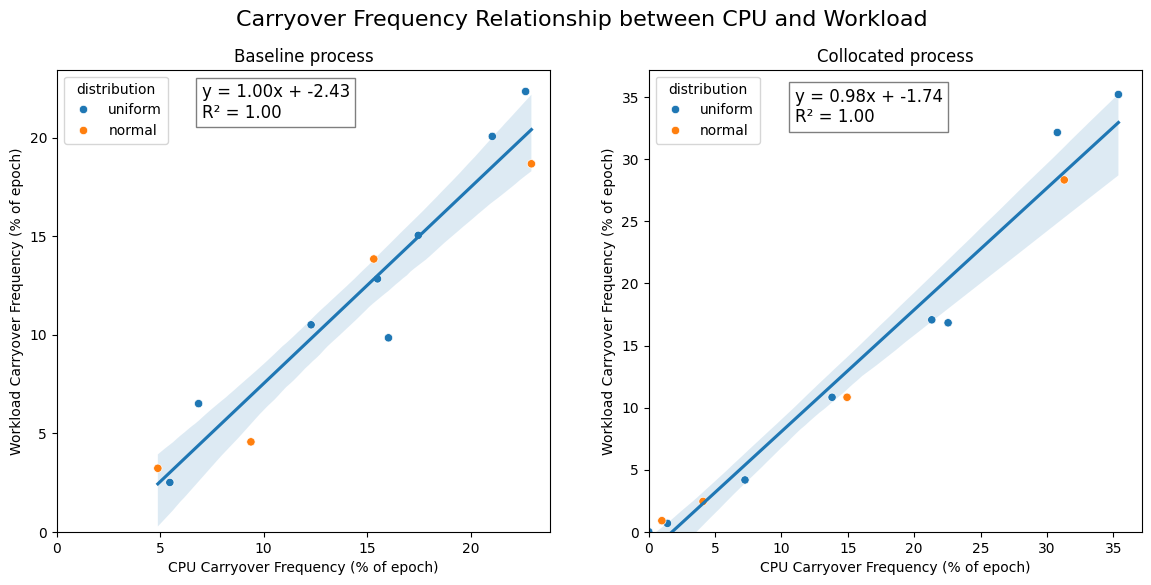

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Carryover Frequency Relationship between CPU and Workload", fontsize=16)

# BASELINE PROCESS
regress_and_plot(
    data,
    ax1,
    x_col="cpu_freq_baseline",
    y_col="work_freq_baseline",
    title="Baseline process",
    x_label="CPU Carryover Frequency (% of epoch)",
    y_label="Workload Carryover Frequency (% of epoch)",
    text_pos=(7, 21)
)

# COLLOCATED PROCESS
regress_and_plot(
    data,
    ax2,
    x_col="cpu_freq_collocated",
    y_col="work_freq_collocated",
    title="Collocated process",
    x_label="CPU Carryover Frequency (% of epoch)",
    y_label="Workload Carryover Frequency (% of epoch)",
    text_pos=(11, 33)
)

print("Ideally, there should be a 1:1 correlation between CPU carryover and workload carryover, so a slope of 1.")

Ideally, there should be a strong, positive, linear association between CPU and workload carryover
The slope gives us the conversion ratio.


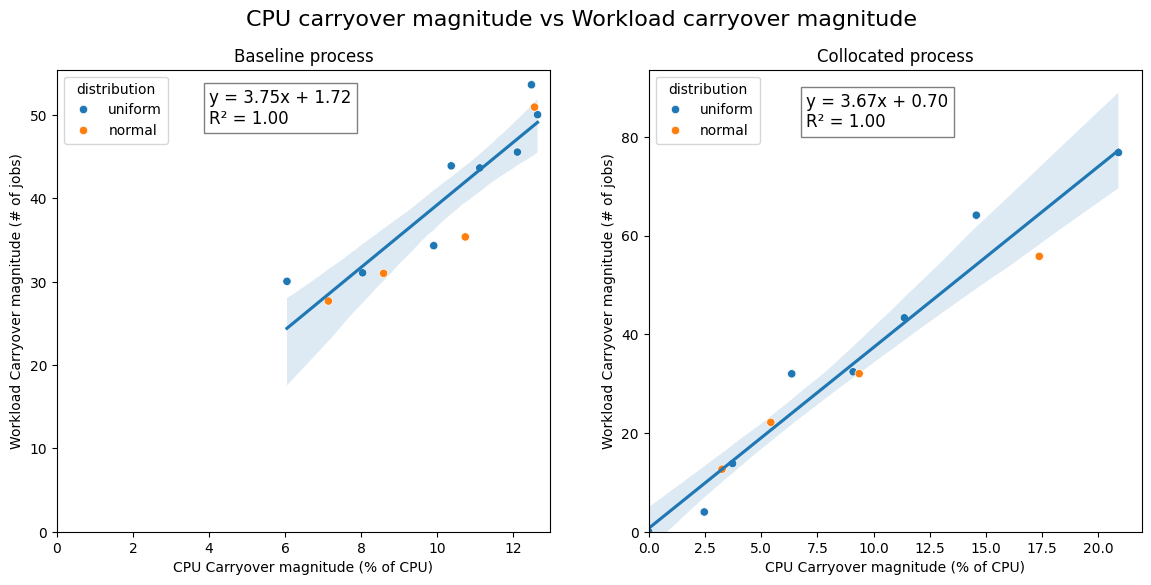

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("CPU carryover magnitude vs Workload carryover magnitude", fontsize=16)

# BASELINE PROCESS
regress_and_plot(
    data,
    ax1,
    x_col="cpu_magnitude_baseline",
    y_col="work_magnitude_baseline",
    title="Baseline process",
    x_label="CPU Carryover magnitude (% of CPU)",
    y_label="Workload Carryover magnitude (# of jobs)",
    text_pos=(4, 49)
)

# COLLOCATED PROCESS
regress_and_plot(
    data,
    ax2,
    x_col="cpu_magnitude_collocated",
    y_col="work_magnitude_collocated",
    title="Collocated process",
    x_label="CPU Carryover magnitude (% of CPU)",
    y_label="Workload Carryover magnitude (# of jobs)",
    text_pos=(7, 82)
)

print("Ideally, there should be a strong, positive, linear association between CPU and workload carryover")
print("The slope gives us the conversion ratio.")

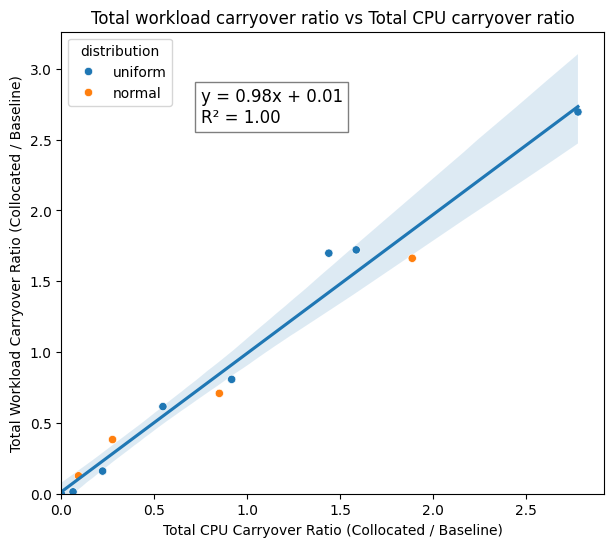

In [8]:
data_totaled = data.copy()
data_totaled["cpu_carryover_baseline"] = data_totaled["cpu_freq_baseline"] * data_totaled["cpu_magnitude_baseline"] / 100
data_totaled["work_carryover_baseline"] = data_totaled["work_freq_baseline"] * data_totaled["work_magnitude_baseline"] / 100
data_totaled["cpu_carryover_collocated"] = data_totaled["cpu_freq_collocated"] * data_totaled["cpu_magnitude_collocated"] / 100
data_totaled["work_carryover_collocated"] = data_totaled["work_freq_collocated"] * data_totaled["work_magnitude_collocated"] / 100

data_totaled["cpu_ratio"] = data_totaled["cpu_carryover_collocated"] / data_totaled["cpu_carryover_baseline"]
data_totaled["work_ratio"] = data_totaled["work_carryover_collocated"] / data_totaled["work_carryover_baseline"]

fig, ax = plt.subplots(1, 1, figsize=(7, 6))

regress_and_plot(
    data_totaled,
    ax,
    x_col="cpu_ratio",
    y_col="work_ratio",
    title="Total workload carryover ratio vs Total CPU carryover ratio",
    x_label="Total CPU Carryover Ratio (Collocated / Baseline)",
    y_label="Total Workload Carryover Ratio (Collocated / Baseline)",
    text_pos=(0.75, 2.62)
)

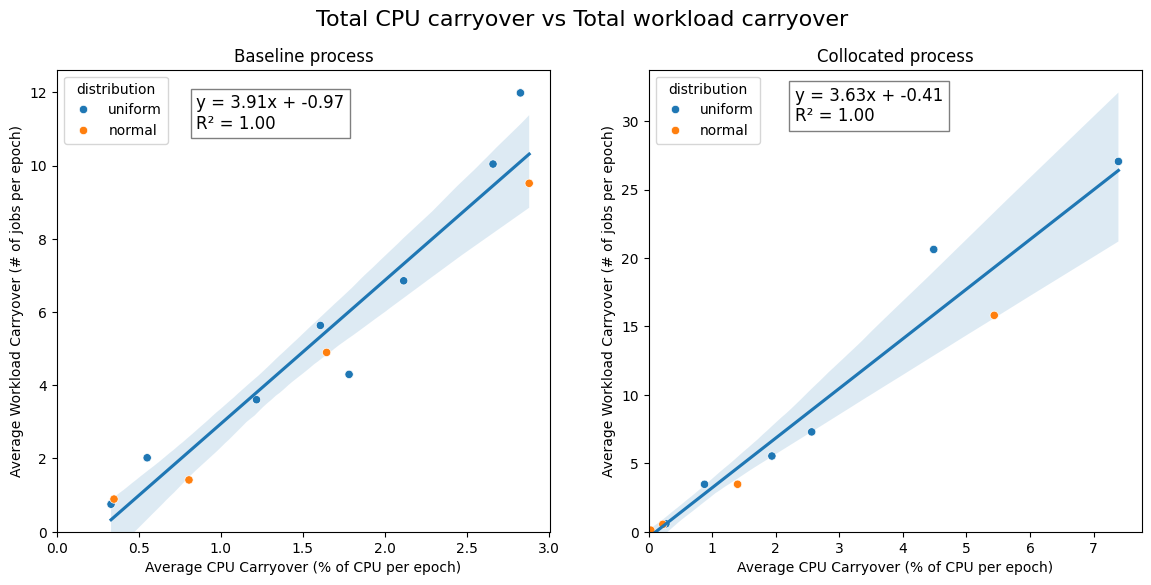

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Total CPU carryover vs Total workload carryover", fontsize=16)

# BASELINE PROCESS
regress_and_plot(
    data_totaled,
    ax1,
    x_col="cpu_carryover_baseline",
    y_col="work_carryover_baseline",
    title="Baseline process",
    x_label="Average CPU Carryover (% of CPU per epoch)",
    y_label="Average Workload Carryover (# of jobs per epoch)",
    text_pos=(0.85, 11)
)

# COLLOCATED PROCESS
regress_and_plot(
    data_totaled,
    ax2,
    x_col="cpu_carryover_collocated",
    y_col="work_carryover_collocated",
    title="Collocated process",
    x_label="Average CPU Carryover (% of CPU per epoch)",
    y_label="Average Workload Carryover (# of jobs per epoch)",
    text_pos=(2.3, 30)
)